In [7]:
import shutil
import os

source_code_dir = "/kaggle/input/datasets/frazyousaf022/all-iot-ids"
working_code_dir = "/kaggle/working/iot_ids_benchmark"

folders_to_delete = [
    "/kaggle/working/iot_ids_benchmark",
    "/kaggle/working/logs",
    "/kaggle/working/results",
    "/kaggle/working/artifacts",
    "/kaggle/working/models",
    "/kaggle/working/paper_outputs"
]

files_to_delete = [
    "/kaggle/working/paper_outputs.zip"
]

for folder in folders_to_delete:
    if os.path.exists(folder):
        shutil.rmtree(folder)
        print("Deleted:", folder)

for file in files_to_delete:
    if os.path.exists(file):
        os.remove(file)
        print("Deleted:", file)

shutil.copytree(source_code_dir, working_code_dir)

os.makedirs("/kaggle/working/logs", exist_ok=True)
os.makedirs("/kaggle/working/results", exist_ok=True)
os.makedirs("/kaggle/working/artifacts", exist_ok=True)
os.makedirs("/kaggle/working/models", exist_ok=True)
os.makedirs("/kaggle/working/paper_outputs", exist_ok=True)

print("Code copied to:", working_code_dir)
print(os.listdir(working_code_dir))

Deleted: /kaggle/working/iot_ids_benchmark
Deleted: /kaggle/working/logs
Deleted: /kaggle/working/results
Deleted: /kaggle/working/artifacts
Deleted: /kaggle/working/models
Deleted: /kaggle/working/paper_outputs
Code copied to: /kaggle/working/iot_ids_benchmark
['utils.py', '01_decision_tree_full.py', '07_make_final_table.py', '02_random_forest_full.py', 'config.py', 'README.md', '04_lightgbm_full.py', '00_prepare_features.py', '05_mlp_dnn_full.py', '03_xgboost_full_reduced.py', '06_cnn_lstm_attention_full_reduced.py']


In [8]:
from pathlib import Path

code_dir = Path("/kaggle/working/iot_ids_benchmark")
config_path = code_dir / "config.py"
## Configuration

# Example Kaggle path:
# DATASET_PATH = "/kaggle/input/your-dataset-folder/your-dataset.csv"
dataset_path = "/kaggle/input/datasets/frazyousaf022/cic-iot-final-dataset/CIC-IOT-FINAL-DATASET.csv"

text = config_path.read_text()

text = text.replace(
    'DATASET_PATH = "/kaggle/input/YOUR_FOLDER/final_iot_without_mitm.csv"',
    f'DATASET_PATH = "{dataset_path}"'
)

text = text.replace("USE_GPU_FOR_XGBOOST = True", "USE_GPU_FOR_XGBOOST = False")
text = text.replace("DL_EPOCHS = 20", "DL_EPOCHS = 7")
text = text.replace("DL_PATIENCE = 5", "DL_PATIENCE = 2")

if "DROP_FEATURE_COLUMNS" not in text:
    text = text.replace(
        "CORR_THRESHOLD = 0.98",
        "CORR_THRESHOLD = 0.98\n\n# Remove dataset-artifact / non-deployable feature\nDROP_FEATURE_COLUMNS = ['Number']"
    )

config_path.write_text(text)

print("config.py updated successfully.")
!grep DATASET_PATH /kaggle/working/iot_ids_benchmark/config.py
!grep USE_GPU_FOR_XGBOOST /kaggle/working/iot_ids_benchmark/config.py
!grep DL_EPOCHS /kaggle/working/iot_ids_benchmark/config.py
!grep DL_PATIENCE /kaggle/working/iot_ids_benchmark/config.py
!grep DROP_FEATURE_COLUMNS /kaggle/working/iot_ids_benchmark/config.py

config.py updated successfully.
Edit DATASET_PATH before running 00_prepare_features.py.
# DATASET_PATH = "/kaggle/input/your-folder/final_iot_without_mitm.csv"
DATASET_PATH = "/kaggle/input/datasets/frazyousaf022/cic-iot-final-dataset/CIC-IOT-FINAL-DATASET.csv"
USE_GPU_FOR_XGBOOST = False
DL_EPOCHS = 7
DL_PATIENCE = 2
DROP_FEATURE_COLUMNS = ['Number']


In [9]:
from pathlib import Path

code_dir = Path("/kaggle/working/iot_ids_benchmark")

# -------------------------
# Patch utils.py
# -------------------------
p = code_dir / "utils.py"
text = p.read_text()

old_func = """def set_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except Exception:
        pass
"""

new_func = """def set_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    # TensorFlow seed is set only inside deep-learning scripts.
"""

if old_func in text:
    text = text.replace(old_func, new_func)

p.write_text(text)

# -------------------------
# Patch LightGBM script
# -------------------------
p = code_dir / "04_lightgbm_full.py"
text = p.read_text()

if "warnings.filterwarnings" not in text:
    text = text.replace(
        "import os\nimport time\nimport joblib",
        'import os\nimport time\nimport joblib\nimport warnings\nwarnings.filterwarnings("ignore", message="X does not have valid feature names.*")\nwarnings.filterwarnings("ignore", category=UserWarning)'
    )

if "verbosity=-1" not in text:
    text = text.replace(
        'objective="multiclass",',
        'objective="multiclass",\n    verbosity=-1,'
    )

p.write_text(text)

# -------------------------
# Patch DL scripts
# -------------------------
for script in ["05_mlp_dnn_full.py", "06_cnn_lstm_attention_full_reduced.py"]:
    p = code_dir / script
    text = p.read_text()

    if 'os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"' not in text:
        text = text.replace(
            "import os",
            'import os\nos.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"'
        )

    if "tf.random.set_seed(config.RANDOM_SEED)" not in text:
        text = text.replace(
            "set_all_seeds(config.RANDOM_SEED)",
            "set_all_seeds(config.RANDOM_SEED)\ntf.random.set_seed(config.RANDOM_SEED)"
        )

    text = text.replace("verbose=1,", "verbose=0,")

    p.write_text(text)

print("Warning cleanup patch completed.")

Warning cleanup patch completed.


In [10]:
from pathlib import Path

code_dir = Path("/kaggle/working/iot_ids_benchmark")
assert code_dir.exists(), "Code folder not found."

# ============================================================
# Decision Tree: Full + Reduced
# ============================================================

decision_tree_code = r'''
import os
import time
import joblib
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_class_weight

import config
from utils import (
    ensure_dirs, set_all_seeds, load_prepared_npz, compute_metrics,
    benchmark_sklearn_model, model_file_size_mb, save_result
)

set_all_seeds(config.RANDOM_SEED)
ensure_dirs(config.RESULTS_DIR, config.MODELS_DIR)

def run_decision_tree(feature_set_name, npz_name):
    data = load_prepared_npz(os.path.join(config.ARTIFACT_DIR, npz_name))

    X_train = data["X_train"]
    X_test = data["X_test"]
    y_train = data["y_train"]
    y_test = data["y_test"]
    class_names = data["class_names"]

    class_weight = None
    if config.USE_CLASS_WEIGHTS:
        weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
        class_weight = {i: w for i, w in enumerate(weights)}

    model = DecisionTreeClassifier(
        random_state=config.RANDOM_SEED,
        class_weight=class_weight,
    )

    start = time.perf_counter()
    model.fit(X_train, y_train)
    training_time = time.perf_counter() - start

    y_pred = model.predict(X_test)

    model_path = os.path.join(
        config.MODELS_DIR,
        f"decision_tree_{feature_set_name.lower()}.joblib"
    )
    joblib.dump(model, model_path)

    metrics = compute_metrics(
        y_test,
        y_pred,
        class_names,
        benign_label_name=config.BENIGN_LABEL_NAME
    )

    efficiency = benchmark_sklearn_model(
        model,
        X_test,
        sample_size=config.BENCHMARK_SAMPLE_SIZE,
        batch_size=config.BENCHMARK_BATCH_SIZE,
    )

    efficiency["training_time_sec"] = float(training_time)
    efficiency["model_size_mb"] = float(model_file_size_mb(model_path))

    result = {
        "model": "DecisionTree",
        "feature_set": feature_set_name,
        "features_used": data["feature_names"],
        "metrics": metrics,
        "efficiency": efficiency,
    }

    print(f"\\n=== Decision Tree {feature_set_name} ===")
    print(metrics["classification_report"])
    save_result(result, config.RESULTS_DIR, "DecisionTree", feature_set_name)

run_decision_tree("Full", "full_tree.npz")
run_decision_tree("Reduced", "reduced_tree.npz")
'''
(code_dir / "01_decision_tree_full.py").write_text(decision_tree_code)

# ============================================================
# Random Forest: Full + Reduced
# ============================================================

random_forest_code = r'''
import os
import time
import joblib

from sklearn.ensemble import RandomForestClassifier

import config
from utils import (
    ensure_dirs, set_all_seeds, load_prepared_npz, compute_metrics,
    benchmark_sklearn_model, model_file_size_mb, save_result
)

set_all_seeds(config.RANDOM_SEED)
ensure_dirs(config.RESULTS_DIR, config.MODELS_DIR)

def run_random_forest(feature_set_name, npz_name):
    data = load_prepared_npz(os.path.join(config.ARTIFACT_DIR, npz_name))

    X_train = data["X_train"]
    X_test = data["X_test"]
    y_train = data["y_train"]
    y_test = data["y_test"]
    class_names = data["class_names"]

    model = RandomForestClassifier(
        n_estimators=250,
        max_depth=None,
        min_samples_leaf=1,
        random_state=config.RANDOM_SEED,
        n_jobs=-1,
        class_weight="balanced" if config.USE_CLASS_WEIGHTS else None,
    )

    start = time.perf_counter()
    model.fit(X_train, y_train)
    training_time = time.perf_counter() - start

    y_pred = model.predict(X_test)

    model_path = os.path.join(
        config.MODELS_DIR,
        f"random_forest_{feature_set_name.lower()}.joblib"
    )
    joblib.dump(model, model_path)

    metrics = compute_metrics(
        y_test,
        y_pred,
        class_names,
        benign_label_name=config.BENIGN_LABEL_NAME
    )

    efficiency = benchmark_sklearn_model(
        model,
        X_test,
        sample_size=config.BENCHMARK_SAMPLE_SIZE,
        batch_size=config.BENCHMARK_BATCH_SIZE,
    )

    efficiency["training_time_sec"] = float(training_time)
    efficiency["model_size_mb"] = float(model_file_size_mb(model_path))

    result = {
        "model": "RandomForest",
        "feature_set": feature_set_name,
        "features_used": data["feature_names"],
        "metrics": metrics,
        "efficiency": efficiency,
    }

    print(f"\\n=== Random Forest {feature_set_name} ===")
    print(metrics["classification_report"])
    save_result(result, config.RESULTS_DIR, "RandomForest", feature_set_name)

run_random_forest("Full", "full_tree.npz")
run_random_forest("Reduced", "reduced_tree.npz")
'''
(code_dir / "02_random_forest_full.py").write_text(random_forest_code)

# ============================================================
# LightGBM: Full + Reduced
# ============================================================

lightgbm_code = r'''
import os
import time
import joblib
import warnings

warnings.filterwarnings("ignore", message="X does not have valid feature names.*")
warnings.filterwarnings("ignore", category=UserWarning)

import config
from utils import (
    ensure_dirs, set_all_seeds, load_prepared_npz, compute_metrics,
    benchmark_sklearn_model, model_file_size_mb, save_result
)

set_all_seeds(config.RANDOM_SEED)
ensure_dirs(config.RESULTS_DIR, config.MODELS_DIR)

try:
    from lightgbm import LGBMClassifier
except ImportError as e:
    raise ImportError("LightGBM is not installed. In Kaggle, try: !pip install lightgbm") from e

def run_lightgbm(feature_set_name, npz_name):
    data = load_prepared_npz(os.path.join(config.ARTIFACT_DIR, npz_name))

    X_train = data["X_train"]
    X_val = data["X_val"]
    X_test = data["X_test"]
    y_train = data["y_train"]
    y_val = data["y_val"]
    y_test = data["y_test"]
    class_names = data["class_names"]

    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=64,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=config.RANDOM_SEED,
        n_jobs=-1,
        objective="multiclass",
        verbosity=-1,
        class_weight="balanced" if config.USE_CLASS_WEIGHTS else None,
    )

    start = time.perf_counter()
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="multi_logloss",
    )
    training_time = time.perf_counter() - start

    y_pred = model.predict(X_test)

    model_path = os.path.join(
        config.MODELS_DIR,
        f"lightgbm_{feature_set_name.lower()}.joblib"
    )
    joblib.dump(model, model_path)

    metrics = compute_metrics(
        y_test,
        y_pred,
        class_names,
        benign_label_name=config.BENIGN_LABEL_NAME
    )

    efficiency = benchmark_sklearn_model(
        model,
        X_test,
        sample_size=config.BENCHMARK_SAMPLE_SIZE,
        batch_size=config.BENCHMARK_BATCH_SIZE,
    )

    efficiency["training_time_sec"] = float(training_time)
    efficiency["model_size_mb"] = float(model_file_size_mb(model_path))

    result = {
        "model": "LightGBM",
        "feature_set": feature_set_name,
        "features_used": data["feature_names"],
        "metrics": metrics,
        "efficiency": efficiency,
    }

    print(f"\\n=== LightGBM {feature_set_name} ===")
    print(metrics["classification_report"])
    save_result(result, config.RESULTS_DIR, "LightGBM", feature_set_name)

run_lightgbm("Full", "full_tree.npz")
run_lightgbm("Reduced", "reduced_tree.npz")
'''
(code_dir / "04_lightgbm_full.py").write_text(lightgbm_code)

# ============================================================
# MLP/DNN: Full + Reduced
# ============================================================

mlp_code = r'''
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import time
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

import config
from utils import (
    ensure_dirs, set_all_seeds, load_prepared_npz, compute_metrics,
    benchmark_keras_model, model_file_size_mb, save_result
)

set_all_seeds(config.RANDOM_SEED)
tf.random.set_seed(config.RANDOM_SEED)

ensure_dirs(config.RESULTS_DIR, config.MODELS_DIR)

print("TensorFlow devices:", tf.config.list_physical_devices())

def build_mlp(input_dim, num_classes):
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(128, activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.20)(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def run_mlp(feature_set_name, npz_name):
    data = load_prepared_npz(os.path.join(config.ARTIFACT_DIR, npz_name))

    X_train = data["X_train"]
    X_val = data["X_val"]
    X_test = data["X_test"]
    y_train = data["y_train"]
    y_val = data["y_val"]
    y_test = data["y_test"]
    class_names = data["class_names"]
    num_classes = len(class_names)

    model = build_mlp(X_train.shape[1], num_classes)

    cb = [
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=config.DL_PATIENCE,
            min_delta=1e-4,
            restore_best_weights=True,
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=1,
            min_lr=1e-6,
        ),
    ]

    start = time.perf_counter()
    model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=config.DL_EPOCHS,
        batch_size=config.DL_BATCH_SIZE,
        callbacks=cb,
        verbose=0,
    )
    training_time = time.perf_counter() - start

    y_prob = model.predict(X_test, batch_size=config.DL_BATCH_SIZE, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    model_path = os.path.join(
        config.MODELS_DIR,
        f"mlp_dnn_{feature_set_name.lower()}.keras"
    )
    model.save(model_path)

    metrics = compute_metrics(
        y_test,
        y_pred,
        class_names,
        benign_label_name=config.BENIGN_LABEL_NAME
    )

    efficiency = benchmark_keras_model(
        model,
        X_test,
        sample_size=config.BENCHMARK_SAMPLE_SIZE,
        batch_size=config.BENCHMARK_BATCH_SIZE,
        reshape_for_sequence=False,
    )

    efficiency["training_time_sec"] = float(training_time)
    efficiency["model_size_mb"] = float(model_file_size_mb(model_path))

    result = {
        "model": "MLP_DNN",
        "feature_set": feature_set_name,
        "features_used": data["feature_names"],
        "metrics": metrics,
        "efficiency": efficiency,
        "parameters": int(model.count_params()),
    }

    print(f"\\n=== MLP/DNN {feature_set_name} ===")
    print(metrics["classification_report"])
    save_result(result, config.RESULTS_DIR, "MLP_DNN", feature_set_name)

run_mlp("Full", "full_scaled.npz")
run_mlp("Reduced", "reduced_scaled.npz")
'''
(code_dir / "05_mlp_dnn_full.py").write_text(mlp_code)

print("Patched all missing models for Full + Reduced.")

Patched all missing models for Full + Reduced.


In [11]:
from pathlib import Path

code_dir = Path("/kaggle/working/iot_ids_benchmark")

# =========================
# 1. Verify config.py
# =========================
config_text = (code_dir / "config.py").read_text()

required_config_items = [
    'DATASET_PATH = "/kaggle/input/datasets/frazyousaf022/cic-iot-final-dataset/CIC-IOT-FINAL-DATASET.csv"',
    "USE_GPU_FOR_XGBOOST = False",
    "DL_EPOCHS = 7",
    "DL_PATIENCE = 2",
    "TOP_K_FEATURES = 15",
    "DROP_FEATURE_COLUMNS = ['Number']"
]

print("Checking config.py...")
for item in required_config_items:
    if item in config_text:
        print("OK:", item)
    else:
        print("MISSING:", item)


# =========================
# 2. Patch 00_prepare_features.py if Number removal is missing
# =========================
prepare_path = code_dir / "00_prepare_features.py"
text = prepare_path.read_text()

if "manual_drop_present" not in text:
    target = """numeric_feature_cols = []
for c in feature_cols:
    if pd.api.types.is_numeric_dtype(df[c]):
        numeric_feature_cols.append(c)"""

    replacement = """numeric_feature_cols = []
for c in feature_cols:
    if pd.api.types.is_numeric_dtype(df[c]):
        numeric_feature_cols.append(c)

# Manually drop likely dataset-artifact / non-deployable features
manual_drop = getattr(config, "DROP_FEATURE_COLUMNS", [])
manual_drop_present = [c for c in manual_drop if c in numeric_feature_cols]
numeric_feature_cols = [c for c in numeric_feature_cols if c not in manual_drop_present]
print("\\nManually dropped columns:", manual_drop_present)"""

    if target in text:
        text = text.replace(target, replacement)
        prepare_path.write_text(text)
        print("Patched 00_prepare_features.py to remove Number.")
    else:
        print("WARNING: Could not patch 00_prepare_features.py automatically.")
else:
    print("00_prepare_features.py already contains manual feature removal.")


# =========================
# 3. Verify reduced-feature support
# =========================
scripts_to_check = [
    "01_decision_tree_full.py",
    "02_random_forest_full.py",
    "03_xgboost_full_reduced.py",
    "04_lightgbm_full.py",
    "05_mlp_dnn_full.py",
    "06_cnn_lstm_attention_full_reduced.py"
]

print("\nChecking reduced-feature support...")
for script in scripts_to_check:
    script_text = (code_dir / script).read_text()
    if "Reduced" in script_text and "reduced_" in script_text:
        print("OK:", script)
    else:
        print("CHECK NEEDED:", script, "may not run reduced features.")

Checking config.py...
OK: DATASET_PATH = "/kaggle/input/datasets/frazyousaf022/cic-iot-final-dataset/CIC-IOT-FINAL-DATASET.csv"
OK: USE_GPU_FOR_XGBOOST = False
OK: DL_EPOCHS = 7
OK: DL_PATIENCE = 2
OK: TOP_K_FEATURES = 15
OK: DROP_FEATURE_COLUMNS = ['Number']
Patched 00_prepare_features.py to remove Number.

Checking reduced-feature support...
OK: 01_decision_tree_full.py
OK: 02_random_forest_full.py
OK: 03_xgboost_full_reduced.py
OK: 04_lightgbm_full.py
OK: 05_mlp_dnn_full.py
OK: 06_cnn_lstm_attention_full_reduced.py


In [12]:
import os
import subprocess

CODE_DIR = "/kaggle/working/iot_ids_benchmark"
LOG_DIR = "/kaggle/working/logs"

os.makedirs(LOG_DIR, exist_ok=True)

scripts = [
    "00_prepare_features.py",
    "01_decision_tree_full.py",
    "02_random_forest_full.py",
    "03_xgboost_full_reduced.py",
    "04_lightgbm_full.py",
    "05_mlp_dnn_full.py",
    "06_cnn_lstm_attention_full_reduced.py",
    "07_make_final_table.py",
]

warning_filters = [
    "Unable to register cuFFT factory",
    "Unable to register cuDNN factory",
    "Unable to register cuBLAS factory",
    "computation placer already registered",
    "X does not have valid feature names",
    "No further splits with positive gain",
    "WARNING: All log messages before absl::InitializeLog",
    "This TensorFlow binary is optimized",
]

def filter_warnings(text):
    clean_lines = []
    for line in text.splitlines():
        if not any(w in line for w in warning_filters):
            clean_lines.append(line)
    return "\n".join(clean_lines)

for script in scripts:
    print("\n" + "=" * 90)
    print(f"Running: {script}")
    print("=" * 90)

    log_path = os.path.join(LOG_DIR, script.replace(".py", ".log"))

    result = subprocess.run(
        ["python", script],
        cwd=CODE_DIR,
        capture_output=True,
        text=True
    )

    full_log = "STDOUT:\n" + result.stdout + "\n\nSTDERR:\n" + result.stderr

    with open(log_path, "w") as f:
        f.write(full_log)

    clean_stdout = filter_warnings(result.stdout)
    clean_stderr = filter_warnings(result.stderr)

    if clean_stdout.strip():
        print(clean_stdout)

    if result.returncode != 0:
        print("\nSCRIPT FAILED.")
        print("Clean error output:")
        print(clean_stderr[-4000:])
        print("\nFull log saved to:", log_path)
        break
    else:
        print(f"\nFinished successfully: {script}")
        print("Log saved to:", log_path)


Running: 00_prepare_features.py
Loading dataset: /kaggle/input/datasets/frazyousaf022/cic-iot-final-dataset/CIC-IOT-FINAL-DATASET.csv
Original shape: (974886, 39)

Original label distribution:
Label
Benign    362342
DoS       274329
DDoS      265943
Mirai      72272
Name: count, dtype: int64

Manually dropped columns: ['Number']

Dropped non-numeric columns: ['Number']

Feature shape before optional correlation filter: (974886, 37)
Final full feature count: 37

Classes: ['Benign', 'DDoS', 'DoS', 'Mirai']

Label distribution after cleaning:
Label
Benign    362342
DoS       274329
DDoS      265943
Mirai      72272
Name: count, dtype: int64

Split shapes:
Train: (682420, 37)
Val  : (146233, 37)
Test : (146233, 37)

Training XGBoost feature selector...
Feature selector training time sec: 36.079

Top selected features:
['ack_flag_number', 'UDP', 'TCP', 'Tot sum', 'ack_count', 'Min', 'Header_Length', 'AVG', 'Protocol Type', 'IAT', 'syn_count', 'rst_count', 'HTTPS', 'Max', 'Rate']
Saved: /ka

In [13]:
import pandas as pd
import os

results_path = "/kaggle/working/results/final_model_comparison.csv"

if os.path.exists(results_path):
    results = pd.read_csv(results_path)
    print("Number of rows:", len(results))
    display(results)
else:
    print("final_model_comparison.csv not found.")

Number of rows: 12


,model,feature_set,accuracy,macro_f1,weighted_f1,fp_per_10000_benign,training_time_sec,total_inference_time_sec,mean_latency_ms_per_sample,p95_latency_ms_per_sample,p99_latency_ms_per_sample,throughput_samples_per_sec,model_size_mb
0,XGBoost,Full,0.999822,0.999680,0.999822,0.000000,81.420405,0.858069,0.017173,0.017749,0.020767,5.827038e+04,3.770559
1,LightGBM,Full,0.999815,0.999674,0.999815,0.000000,44.994743,2.082595,0.041648,0.044221,0.046481,2.400851e+04,6.982258
2,RandomForest,Full,0.999740,0.999541,0.999740,0.000000,98.828229,7.978155,0.159789,0.170268,0.172558,6.267113e+03,18.067300
3,MLP_DNN,Full,0.999610,0.999380,0.999610,0.367979,32.573528,5.630309,0.115385,0.115222,0.142464,8.880507e+03,0.229210
4,DecisionTree,Full,0.999583,0.999238,0.999583,0.367979,5.599820,0.018581,0.000368,0.000443,0.000570,2.690955e+06,0.043847
5,CNN_LSTM_Attention,Full,0.999467,0.999090,0.999467,1.287925,78.507372,5.421719,0.108904,0.116434,0.137417,9.222167e+03,0.857542
6,XGBoost,Reduced,0.999754,0.999604,0.999754,0.183989,57.820178,0.923497,0.018481,0.020811,0.021422,5.414201e+04,4.043043
7,LightGBM,Reduced,0.999726,0.999553,0.999726,0.183989,37.533084,2.114256,0.042268,0.057647,0.064927,2.364898e+04,7.525593
8,RandomForest,Reduced,0.999631,0.999375,0.999631,0.000000,68.671200,8.158289,0.163485,0.171332,0.176123,6.128736e+03,17.824685
9,DecisionTree,Reduced,0.999494,0.999193,0.999494,0.367979,3.327752,0.017624,0.000348,0.000390,0.000409,2.837062e+06,0.053918


In [14]:
import os
import pandas as pd

print("Results folder:")
!ls -lah /kaggle/working/results

print("\nArtifacts folder:")
!ls -lah /kaggle/working/artifacts

print("\nLogs folder:")
!ls -lah /kaggle/working/logs

results_path = "/kaggle/working/results/final_model_comparison.csv"

if os.path.exists(results_path):
    results = pd.read_csv(results_path)
    display(results)
else:
    print("final_model_comparison.csv not found. Check logs for failed script.")

Results folder:
total 108K
drwxr-xr-x 2 root root 4.0K Apr 23 13:21 .
drwxr-xr-x 9 root root 4.0K Apr 23 13:07 ..
-rw-r--r-- 1 root root 2.8K Apr 23 13:19 CNN_LSTM_Attention_Full_result.json
-rw-r--r-- 1 root root  500 Apr 23 13:19 CNN_LSTM_Attention_Full_summary.csv
-rw-r--r-- 1 root root 2.5K Apr 23 13:21 CNN_LSTM_Attention_Reduced_result.json
-rw-r--r-- 1 root root  504 Apr 23 13:21 CNN_LSTM_Attention_Reduced_summary.csv
-rw-r--r-- 1 root root 2.8K Apr 23 13:09 DecisionTree_Full_result.json
-rw-r--r-- 1 root root  509 Apr 23 13:09 DecisionTree_Full_summary.csv
-rw-r--r-- 1 root root 2.5K Apr 23 13:09 DecisionTree_Reduced_result.json
-rw-r--r-- 1 root root  508 Apr 23 13:09 DecisionTree_Reduced_summary.csv
-rw-r--r-- 1 root root 2.8K Apr 23 13:21 final_model_comparison.csv
-rw-r--r-- 1 root root 2.7K Apr 23 13:15 LightGBM_Full_result.json
-rw-r--r-- 1 root root  479 Apr 23 13:15 LightGBM_Full_summary.csv
-rw-r--r-- 1 root root 2.4K Apr 23 13:16 LightGBM_Reduced_result.json
-rw-r--r--

,model,feature_set,accuracy,macro_f1,weighted_f1,fp_per_10000_benign,training_time_sec,total_inference_time_sec,mean_latency_ms_per_sample,p95_latency_ms_per_sample,p99_latency_ms_per_sample,throughput_samples_per_sec,model_size_mb
0,XGBoost,Full,0.999822,0.999680,0.999822,0.000000,81.420405,0.858069,0.017173,0.017749,0.020767,5.827038e+04,3.770559
1,LightGBM,Full,0.999815,0.999674,0.999815,0.000000,44.994743,2.082595,0.041648,0.044221,0.046481,2.400851e+04,6.982258
2,RandomForest,Full,0.999740,0.999541,0.999740,0.000000,98.828229,7.978155,0.159789,0.170268,0.172558,6.267113e+03,18.067300
3,MLP_DNN,Full,0.999610,0.999380,0.999610,0.367979,32.573528,5.630309,0.115385,0.115222,0.142464,8.880507e+03,0.229210
4,DecisionTree,Full,0.999583,0.999238,0.999583,0.367979,5.599820,0.018581,0.000368,0.000443,0.000570,2.690955e+06,0.043847
5,CNN_LSTM_Attention,Full,0.999467,0.999090,0.999467,1.287925,78.507372,5.421719,0.108904,0.116434,0.137417,9.222167e+03,0.857542
6,XGBoost,Reduced,0.999754,0.999604,0.999754,0.183989,57.820178,0.923497,0.018481,0.020811,0.021422,5.414201e+04,4.043043
7,LightGBM,Reduced,0.999726,0.999553,0.999726,0.183989,37.533084,2.114256,0.042268,0.057647,0.064927,2.364898e+04,7.525593
8,RandomForest,Reduced,0.999631,0.999375,0.999631,0.000000,68.671200,8.158289,0.163485,0.171332,0.176123,6.128736e+03,17.824685
9,DecisionTree,Reduced,0.999494,0.999193,0.999494,0.367979,3.327752,0.017624,0.000348,0.000390,0.000409,2.837062e+06,0.053918


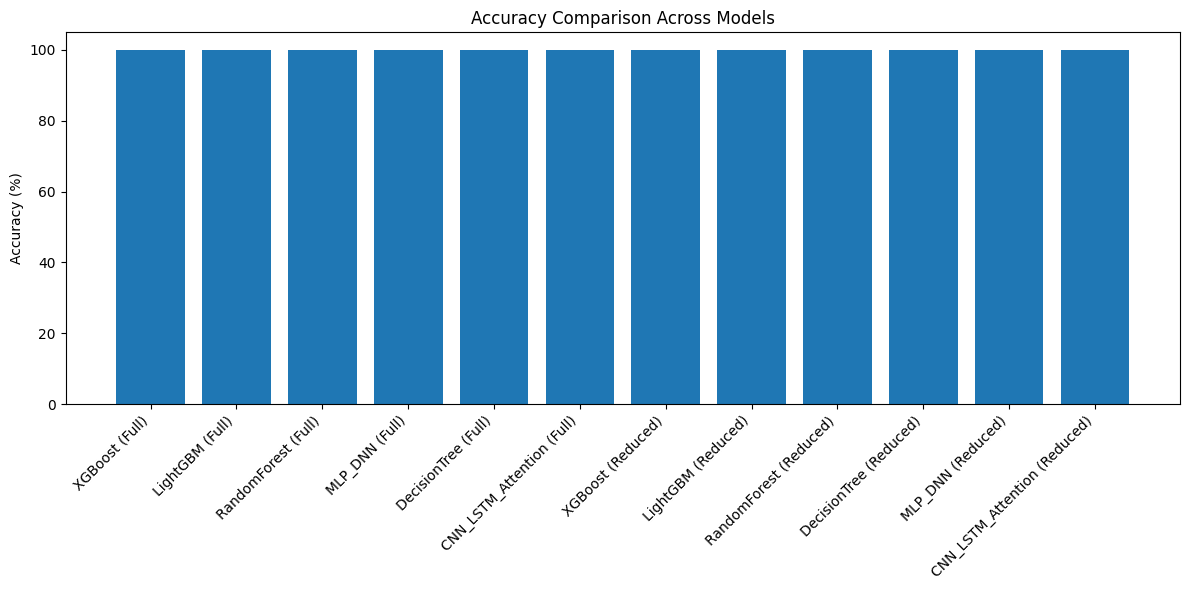

Saved: /kaggle/working/paper_outputs/Fig_Accuracy_Comparison.png


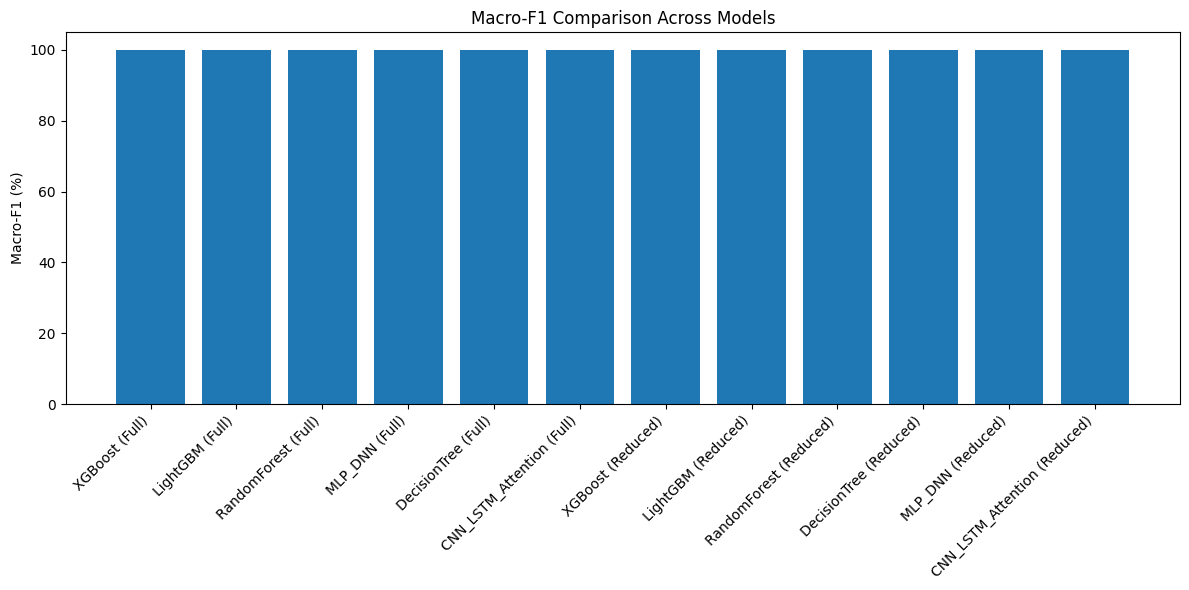

Saved: /kaggle/working/paper_outputs/Fig_MacroF1_Comparison.png


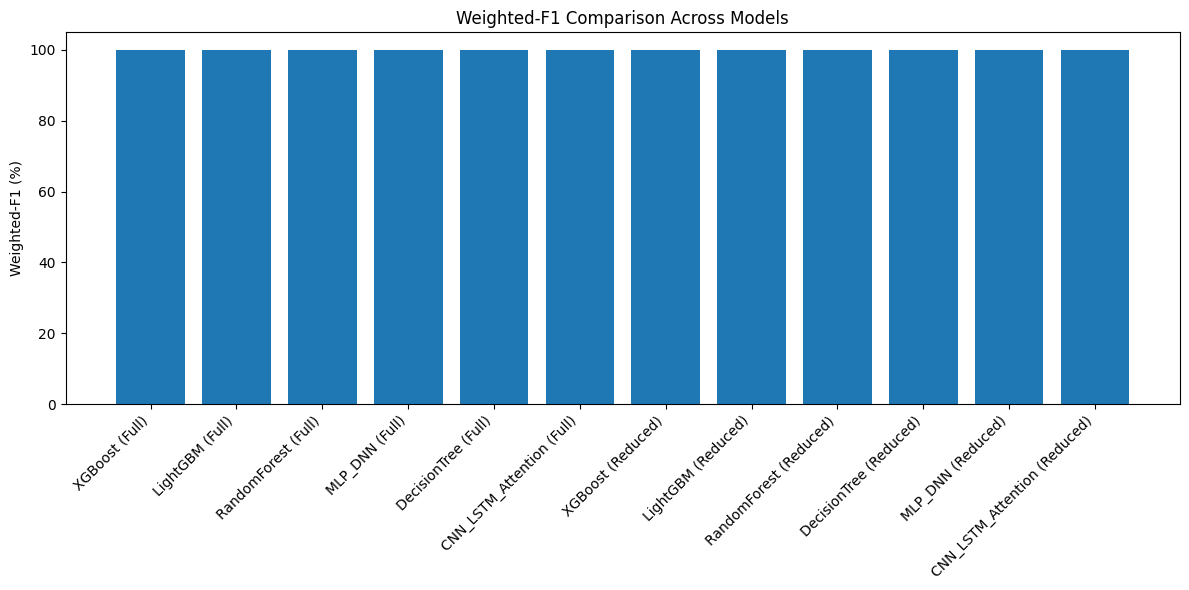

Saved: /kaggle/working/paper_outputs/Fig_WeightedF1_Comparison.png


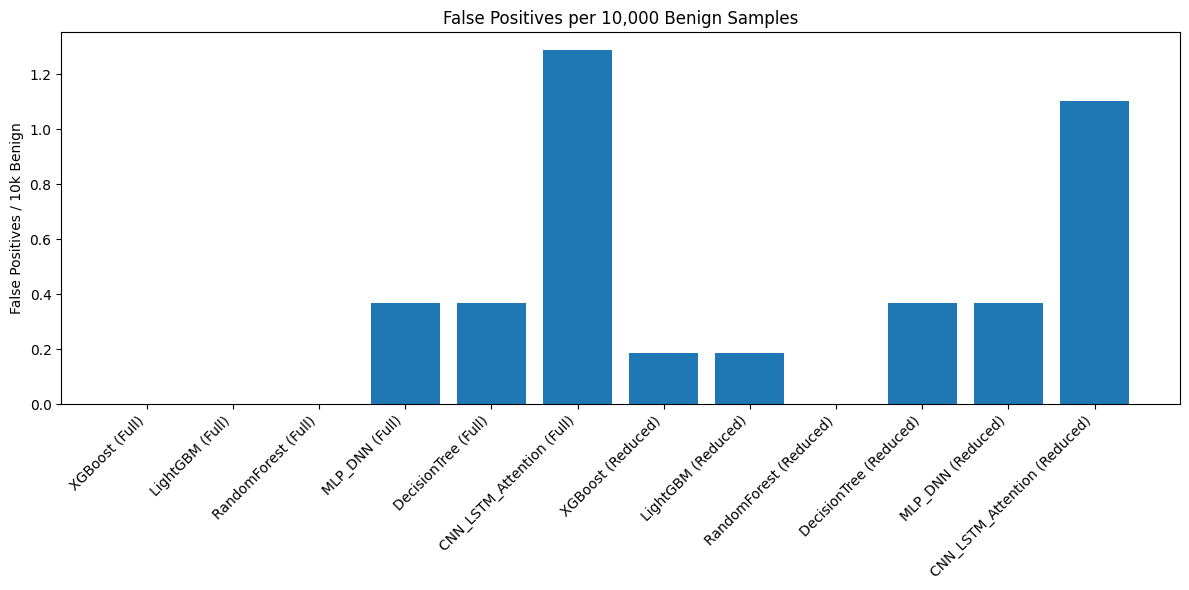

Saved: /kaggle/working/paper_outputs/Fig_FP_per_10000_Benign.png


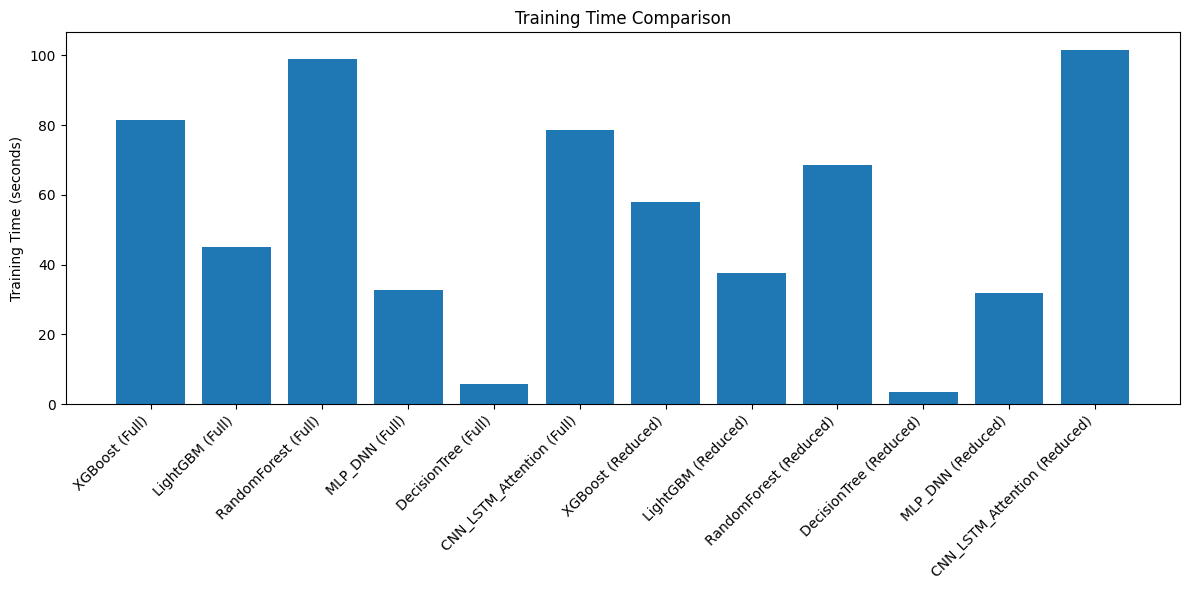

Saved: /kaggle/working/paper_outputs/Fig_Training_Time.png


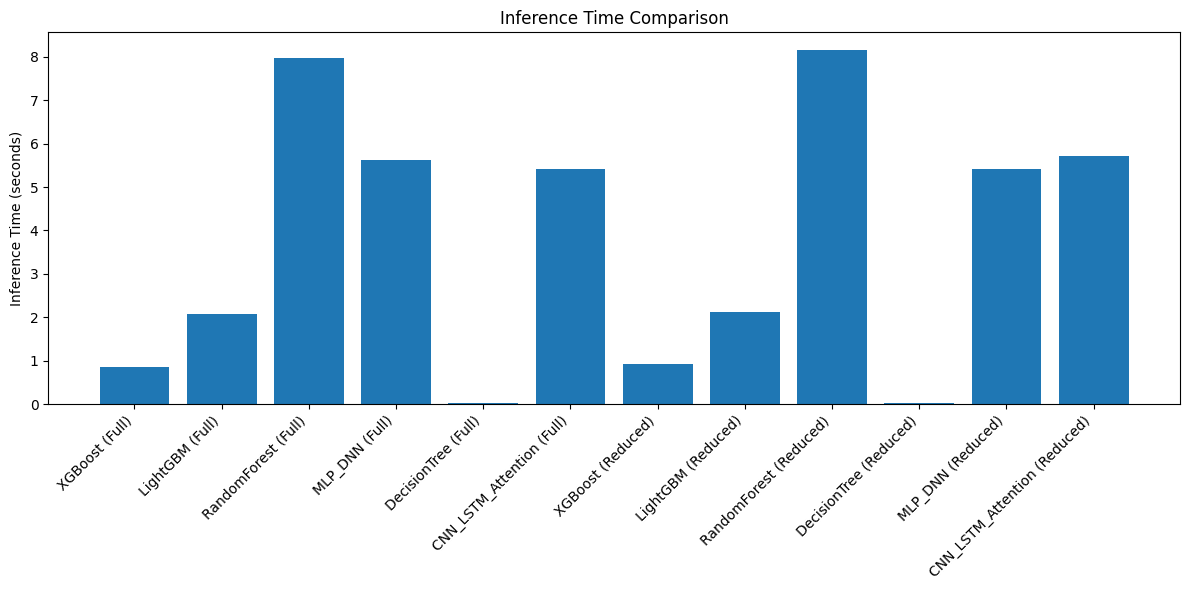

Saved: /kaggle/working/paper_outputs/Fig_Inference_Time.png


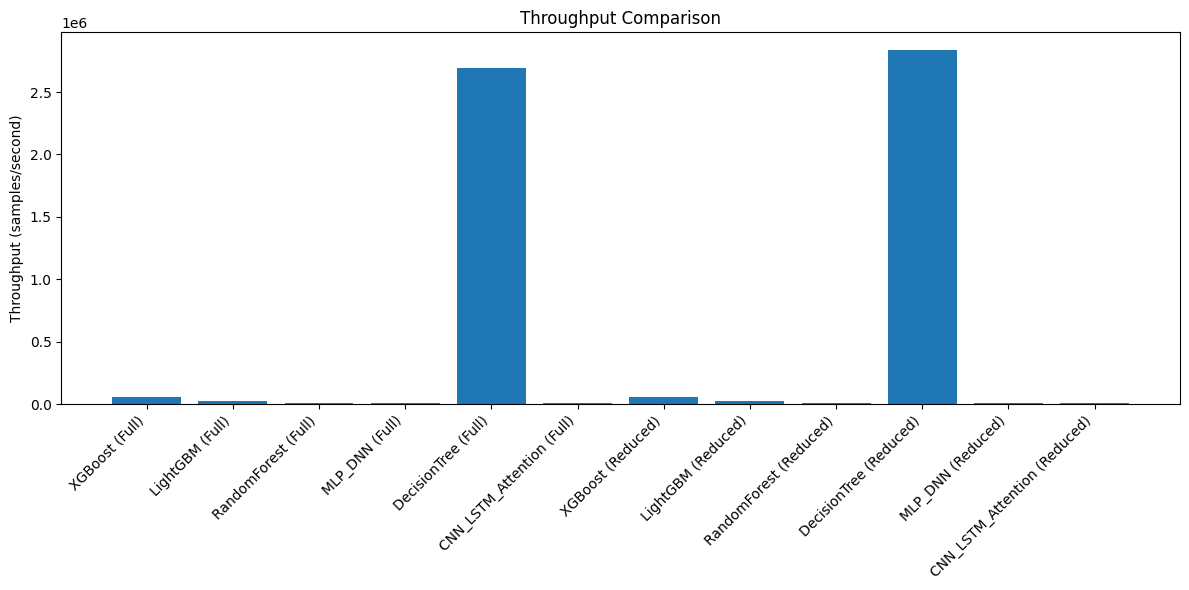

Saved: /kaggle/working/paper_outputs/Fig_Throughput.png


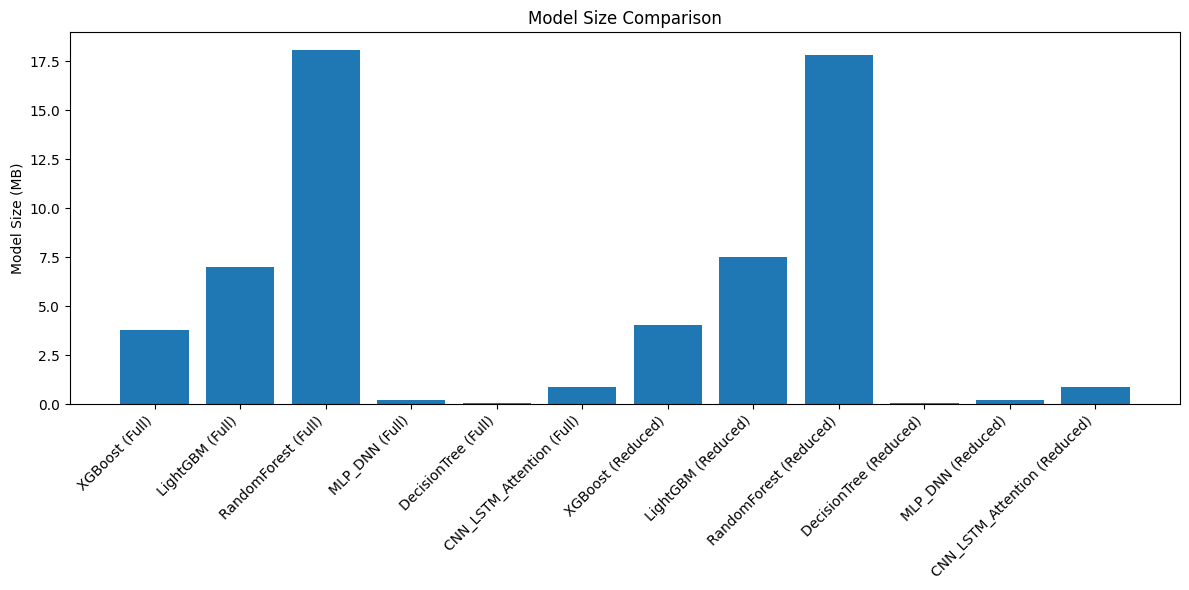

Saved: /kaggle/working/paper_outputs/Fig_Model_Size.png


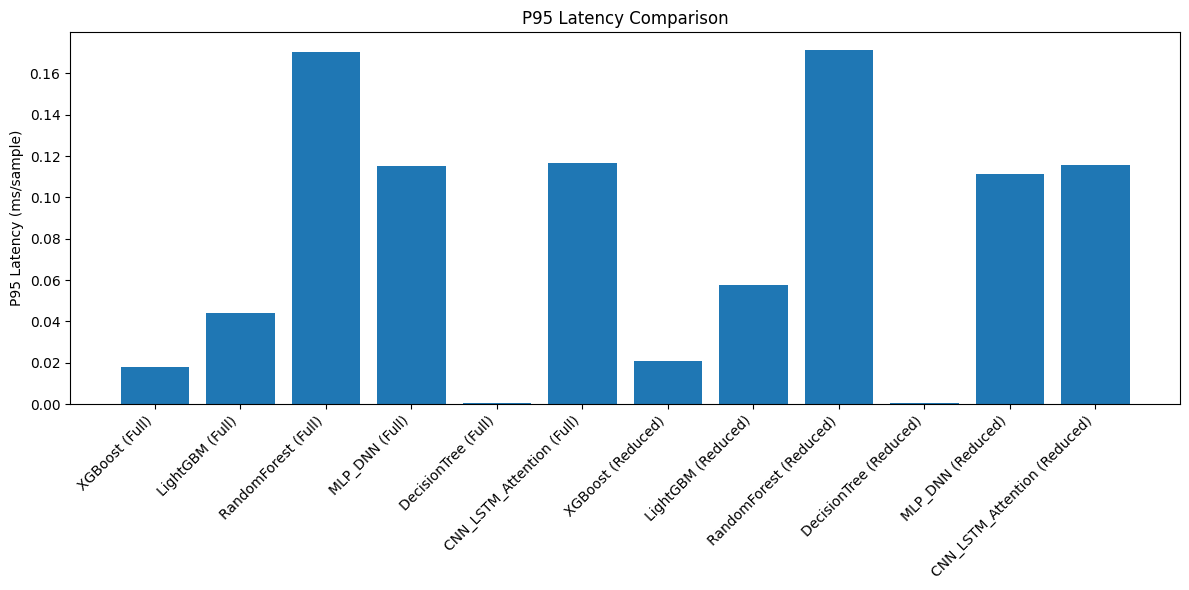

Saved: /kaggle/working/paper_outputs/Fig_P95_Latency.png


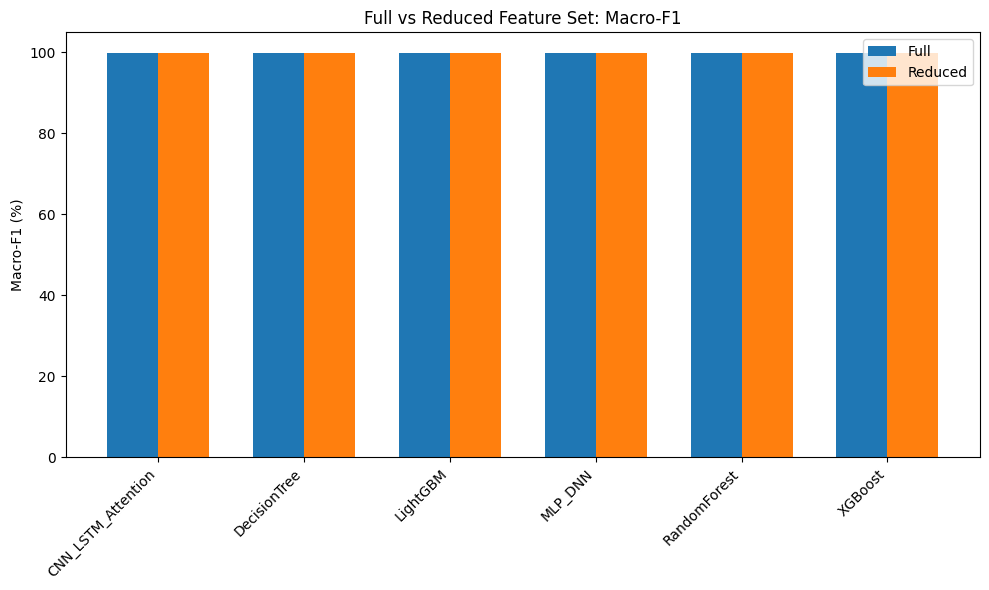

Saved: /kaggle/working/paper_outputs/Fig_Full_vs_Reduced_MacroF1.png


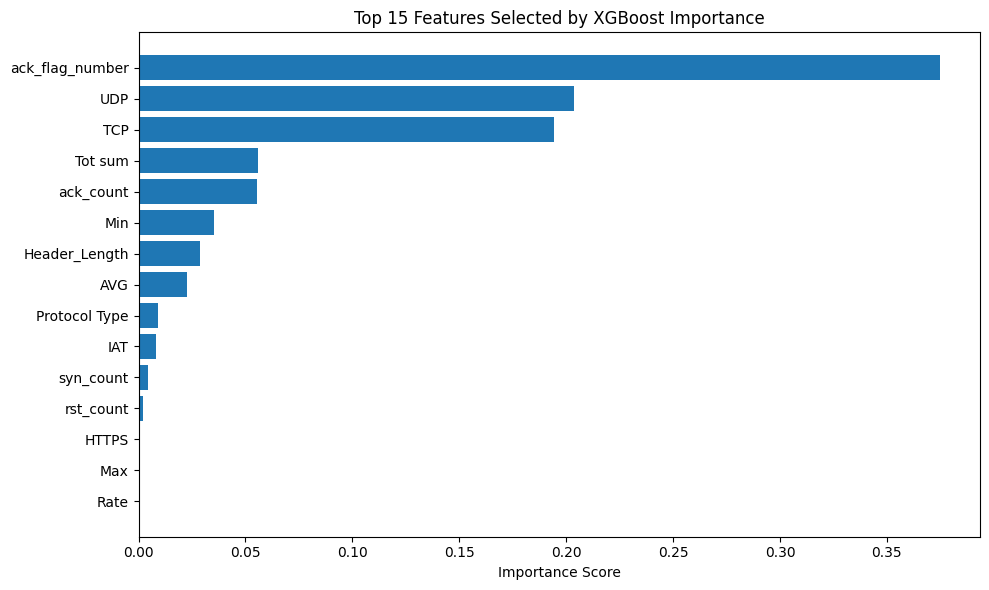

Saved: /kaggle/working/paper_outputs/Fig_Top15_Feature_Importance.png

All paper outputs saved to: /kaggle/working/paper_outputs
Zip created: /kaggle/working/paper_outputs.zip


/kaggle/working/paper_outputs.zip

In [15]:
import os
import json
import glob
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import FileLink

RESULTS_DIR = "/kaggle/working/results"
ARTIFACTS_DIR = "/kaggle/working/artifacts"
PAPER_DIR = "/kaggle/working/paper_outputs"

os.makedirs(PAPER_DIR, exist_ok=True)

final_table_path = os.path.join(RESULTS_DIR, "final_model_comparison.csv")

if not os.path.exists(final_table_path):
    raise FileNotFoundError("final_model_comparison.csv not found. Run the model pipeline first.")

df = pd.read_csv(final_table_path)

# =========================
# Save paper-ready table
# =========================

df_paper = df.copy()

for col in ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]:
    if col in df_paper.columns:
        df_paper[col] = df_paper[col] * 100

rename_map = {
    "model": "Model",
    "feature_set": "Feature Set",
    "accuracy": "Accuracy (%)",
    "balanced_accuracy": "Balanced Accuracy (%)",
    "macro_f1": "Macro-F1 (%)",
    "weighted_f1": "Weighted-F1 (%)",
    "fp_per_10000_benign": "FP / 10k Benign",
    "training_time_sec": "Training Time (s)",
    "total_inference_time_sec": "Inference Time (s)",
    "mean_latency_ms_per_sample": "Mean Latency (ms/sample)",
    "p95_latency_ms_per_sample": "P95 Latency (ms/sample)",
    "p99_latency_ms_per_sample": "P99 Latency (ms/sample)",
    "throughput_samples_per_sec": "Throughput (samples/s)",
    "model_size_mb": "Model Size (MB)",
}

df_paper = df_paper.rename(columns=rename_map)

df_paper.to_csv(os.path.join(PAPER_DIR, "Table_Final_Model_Comparison.csv"), index=False)

try:
    with open(os.path.join(PAPER_DIR, "Table_Final_Model_Comparison.md"), "w") as f:
        f.write(df_paper.to_markdown(index=False))
except Exception:
    with open(os.path.join(PAPER_DIR, "Table_Final_Model_Comparison.md"), "w") as f:
        f.write(df_paper.to_string(index=False))

# =========================
# Plot helper
# =========================

def save_bar_plot(data, x_col, y_col, title, ylabel, filename, rotation=45):
    plt.figure(figsize=(12, 6))
    plt.bar(data[x_col].astype(str), data[y_col])
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    path = os.path.join(PAPER_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

df_plot = df.copy()
df_plot["Model_Features"] = df_plot["model"] + " (" + df_plot["feature_set"] + ")"
df_plot["accuracy_pct"] = df_plot["accuracy"] * 100
df_plot["macro_f1_pct"] = df_plot["macro_f1"] * 100
df_plot["weighted_f1_pct"] = df_plot["weighted_f1"] * 100

# =========================
# Detection graphs
# =========================

save_bar_plot(df_plot, "Model_Features", "accuracy_pct",
              "Accuracy Comparison Across Models", "Accuracy (%)",
              "Fig_Accuracy_Comparison.png")

save_bar_plot(df_plot, "Model_Features", "macro_f1_pct",
              "Macro-F1 Comparison Across Models", "Macro-F1 (%)",
              "Fig_MacroF1_Comparison.png")

save_bar_plot(df_plot, "Model_Features", "weighted_f1_pct",
              "Weighted-F1 Comparison Across Models", "Weighted-F1 (%)",
              "Fig_WeightedF1_Comparison.png")

save_bar_plot(df_plot, "Model_Features", "fp_per_10000_benign",
              "False Positives per 10,000 Benign Samples",
              "False Positives / 10k Benign",
              "Fig_FP_per_10000_Benign.png")

# =========================
# Efficiency graphs
# =========================

save_bar_plot(df_plot, "Model_Features", "training_time_sec",
              "Training Time Comparison", "Training Time (seconds)",
              "Fig_Training_Time.png")

save_bar_plot(df_plot, "Model_Features", "total_inference_time_sec",
              "Inference Time Comparison", "Inference Time (seconds)",
              "Fig_Inference_Time.png")

save_bar_plot(df_plot, "Model_Features", "throughput_samples_per_sec",
              "Throughput Comparison", "Throughput (samples/second)",
              "Fig_Throughput.png")

save_bar_plot(df_plot, "Model_Features", "model_size_mb",
              "Model Size Comparison", "Model Size (MB)",
              "Fig_Model_Size.png")

save_bar_plot(df_plot, "Model_Features", "p95_latency_ms_per_sample",
              "P95 Latency Comparison", "P95 Latency (ms/sample)",
              "Fig_P95_Latency.png")

# =========================
# Full vs Reduced Macro-F1
# =========================

pivot_macro = df_plot.pivot_table(
    index="model",
    columns="feature_set",
    values="macro_f1_pct",
    aggfunc="mean"
).reset_index()

if "Full" in pivot_macro.columns and "Reduced" in pivot_macro.columns:
    x = np.arange(len(pivot_macro["model"]))
    width = 0.35

    plt.figure(figsize=(10, 6))
    plt.bar(x - width / 2, pivot_macro["Full"], width, label="Full")
    plt.bar(x + width / 2, pivot_macro["Reduced"], width, label="Reduced")
    plt.title("Full vs Reduced Feature Set: Macro-F1")
    plt.ylabel("Macro-F1 (%)")
    plt.xticks(x, pivot_macro["model"], rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()

    path = os.path.join(PAPER_DIR, "Fig_Full_vs_Reduced_MacroF1.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

# =========================
# Feature importance graph
# =========================

feature_importance_path = os.path.join(ARTIFACTS_DIR, "feature_importance_xgboost.csv")

if os.path.exists(feature_importance_path):
    fi = pd.read_csv(feature_importance_path)
    fi_top = fi.head(15)

    plt.figure(figsize=(10, 6))
    plt.barh(fi_top["feature"][::-1], fi_top["importance"][::-1])
    plt.title("Top 15 Features Selected by XGBoost Importance")
    plt.xlabel("Importance Score")
    plt.tight_layout()

    path = os.path.join(PAPER_DIR, "Fig_Top15_Feature_Importance.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

    fi.to_csv(os.path.join(PAPER_DIR, "Table_XGBoost_Feature_Importance.csv"), index=False)

# =========================
# Confusion matrices
# =========================

cm_dir = os.path.join(PAPER_DIR, "confusion_matrices")
os.makedirs(cm_dir, exist_ok=True)

result_json_files = glob.glob(os.path.join(RESULTS_DIR, "*_result.json"))

for path_json in result_json_files:
    with open(path_json, "r") as f:
        result = json.load(f)

    model_name = result["model"]
    feature_set = result["feature_set"]
    cm = np.array(result["metrics"]["confusion_matrix"])
    class_names = list(result["metrics"]["per_class"].keys())

    plt.figure(figsize=(7, 6))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix: {model_name} ({feature_set})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(np.arange(len(class_names)), class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()

    filename = f"CM_{model_name}_{feature_set}.png".replace("/", "_")
    save_path = os.path.join(cm_dir, filename)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

# =========================
# Best model summary table
# =========================

summary_rows = []

for criterion, col, mode in [
    ("Best Accuracy", "accuracy", "max"),
    ("Best Macro-F1", "macro_f1", "max"),
    ("Lowest FP/10k Benign", "fp_per_10000_benign", "min"),
    ("Highest Throughput", "throughput_samples_per_sec", "max"),
    ("Smallest Model Size", "model_size_mb", "min"),
]:
    idx = df[col].idxmax() if mode == "max" else df[col].idxmin()
    row = df.loc[idx]
    summary_rows.append({
        "Criterion": criterion,
        "Model": row["model"],
        "Feature Set": row["feature_set"],
        "Value": row[col]
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(PAPER_DIR, "Table_Best_Model_By_Criterion.csv"), index=False)

# =========================
# Zip paper outputs
# =========================

zip_path = "/kaggle/working/paper_outputs.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(PAPER_DIR):
        for file in files:
            full_path = os.path.join(root, file)
            arcname = os.path.relpath(full_path, PAPER_DIR)
            zipf.write(full_path, arcname)

print("\nAll paper outputs saved to:", PAPER_DIR)
print("Zip created:", zip_path)

FileLink(zip_path)